In [1]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# load data
df = pd.read_csv("/kaggle/input/datasets/rajkumarpandey02/list-of-countries-by-sugarcane-production/List of Countries by Sugarcane Production.csv")

In [3]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [4]:
df.shape

(103, 7)

# **Data Cleaning**

In [5]:
df['Production (Tons)'] = df['Production (Tons)'].str.replace('.','')
df['Production per Person (Kg)'] = (df['Production per Person (Kg)'].str.replace('.','')).str.replace(',', '.')
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].str.replace('.','')
df['Yield (Kg / Hectare)'] = (df['Yield (Kg / Hectare)'].str.replace('.','')).str.replace(',', '.')

df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [6]:
df.rename(columns={
    'Production (Tons)': 'Production(Tons)',
    'Production per Person (Kg)': 'Production_per_person(Kg)',
    'Acreage (Hectare)': 'Acreage(Hectare)',
    'Yield (Kg / Hectare)': 'Yield(Kg/Hectare)'
}, inplace=True)

df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
df.isnull().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_person(Kg)    0
Acreage(Hectare)             1
Yield(Kg/Hectare)            1
dtype: int64

In [8]:
df[df['Acreage(Hectare)'].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [9]:
df.dropna(axis=0, how='any', inplace=True)
df.isnull().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_person(Kg)    0
Acreage(Hectare)             0
Yield(Kg/Hectare)            0
dtype: int64

In [10]:
df.reset_index(inplace=True)
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [11]:
df.drop(['index', 'Unnamed: 0'], axis=1, inplace=True)

In [12]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Country                    102 non-null    object
 1   Continent                  102 non-null    object
 2   Production(Tons)           102 non-null    object
 3   Production_per_person(Kg)  102 non-null    object
 4   Acreage(Hectare)           102 non-null    object
 5   Yield(Kg/Hectare)          102 non-null    object
dtypes: object(6)
memory usage: 4.9+ KB


In [14]:
df['Production(Tons)'] = df['Production(Tons)'].astype(np.float64)
df['Production_per_person(Kg)'] = df['Production_per_person(Kg)'].astype(np.float64)
df['Acreage(Hectare)'] = df['Acreage(Hectare)'].astype(np.float64)
df['Yield(Kg/Hectare)'] = df['Yield(Kg/Hectare)'].astype(np.float64)

df.dtypes

Country                       object
Continent                     object
Production(Tons)             float64
Production_per_person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg/Hectare)            float64
dtype: object

In [15]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [16]:
print('number of duplicate entries:', df.duplicated().sum())

number of duplicate entries: 0


In [17]:
print('number of unique entries in each column:')
df.nunique()

number of unique entries in each column:


Country                      102
Continent                      6
Production(Tons)             102
Production_per_person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

# **Univariate Analysis**

### **How many countries produce sugarcane from each continent**

In [18]:
ser1 = df['Continent'].value_counts()
ser1

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

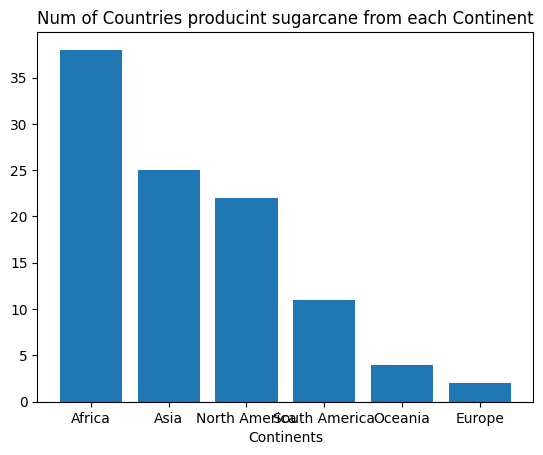

In [19]:
plt.bar(ser1.index, ser1)
plt.xlabel('Continents')
plt.title('Num of Countries producint sugarcane from each Continent')
plt.show()

### **Distribution of numerical columns** 

In [20]:
df.describe()

,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


/tmp/ipykernel_24/411160270.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production(Tons)'], bins=15)
/tmp/ipykernel_24/411160270.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production_per_person(Kg)'], bins=15)
/tmp/ipykernel_24/411160270.py:10: UserWarning: 

`distplot` 

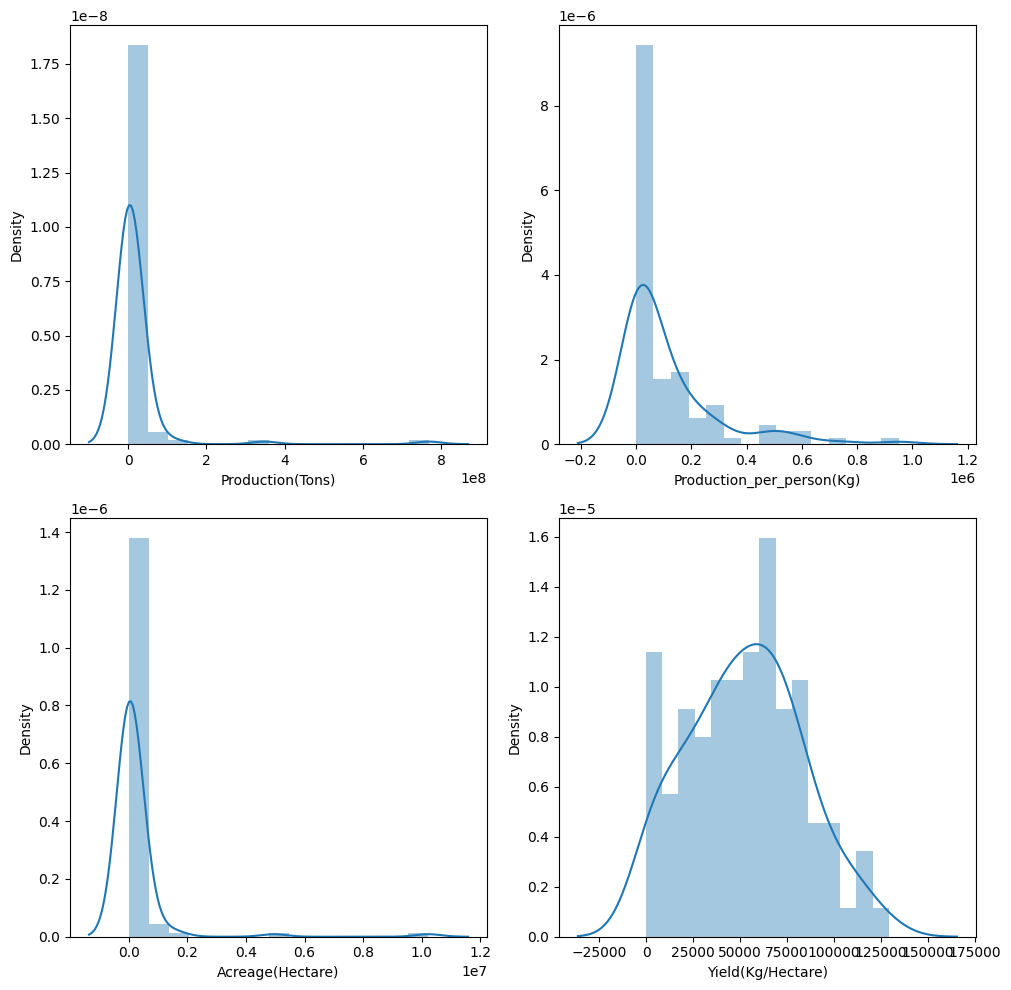

In [21]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
sns.distplot(df['Production(Tons)'], bins=15)

plt.subplot(2, 2, 2)
sns.distplot(df['Production_per_person(Kg)'], bins=15)

plt.subplot(2, 2, 3)
sns.distplot(df['Acreage(Hectare)'], bins=15)

plt.subplot(2, 2, 4)
sns.distplot(df['Yield(Kg/Hectare)'], bins=15)

plt.tight_layout()
plt.show()

### **Checking Outliers**

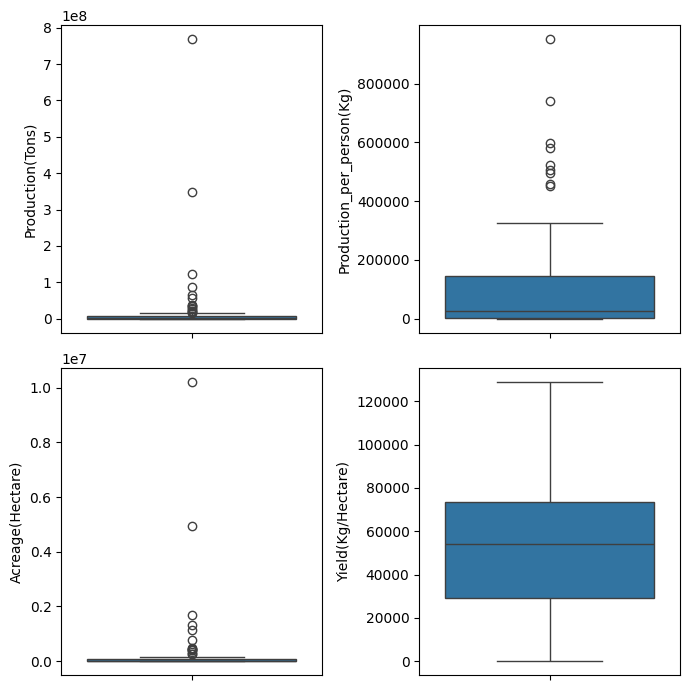

In [22]:
plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
sns.boxplot(df['Production(Tons)'])

plt.subplot(2, 2, 2)
sns.boxplot(df['Production_per_person(Kg)'])

plt.subplot(2, 2, 3)
sns.boxplot(df['Acreage(Hectare)'])

plt.subplot(2, 2, 4)
sns.boxplot(df['Yield(Kg/Hectare)'])

plt.tight_layout()
plt.show()

# **Bivariate Analysis**

### **Which country produces maximum sugarcane?**

In [23]:
print('country with maximum production:')
df[df['Production(Tons)'] == np.max(df['Production(Tons)'])]

country with maximum production:


,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5


In [24]:
total_production = df['Production(Tons)'].sum()
df_new = df[['Country', 'Production(Tons)']].set_index('Country')
df_new['ProductionPercent'] = df_new['Production(Tons)'] / (total_production / 100)
df_new

,Production(Tons),ProductionPercent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: title={'center': 'Top 10 maximum sugarcane producing countries'}, xlabel='Country'>

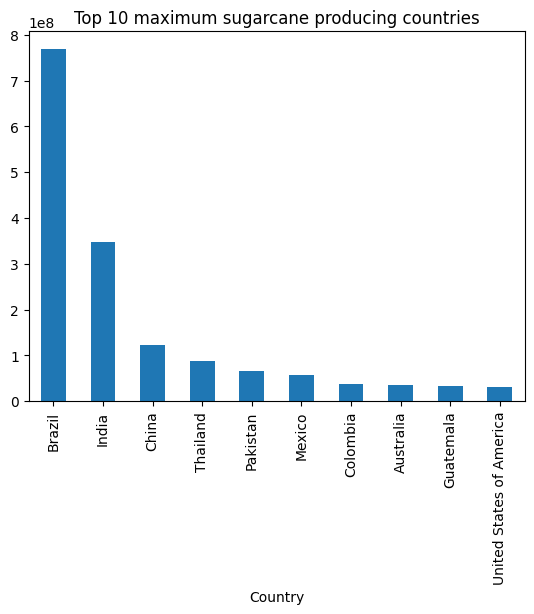

In [25]:
df_new.sort_values(by='Production(Tons)', ascending=False).head(10)['Production(Tons)'].plot(kind='bar', title='Top 10 maximum sugarcane producing countries')

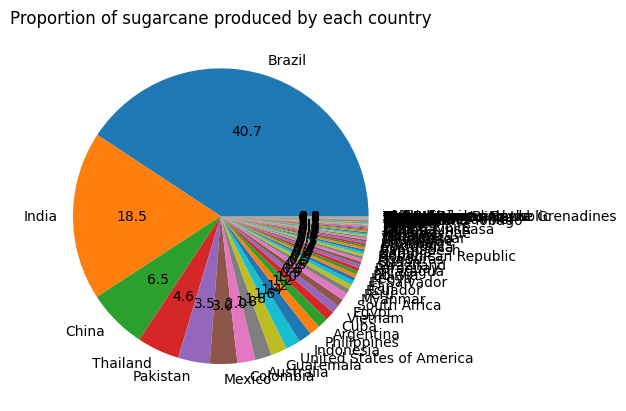

In [26]:
plt.pie(df_new['ProductionPercent'], labels=df_new.index, autopct='%.1f')
plt.title('Proportion of sugarcane produced by each country')
plt.show()

### **Which country has most land?**

In [27]:
print('country with most land:')
df[df['Acreage(Hectare)'] == df['Acreage(Hectare)'].max()]

country with most land:


,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5


<Axes: title={'center': 'Top 10 countries with most land'}, xlabel='Country'>

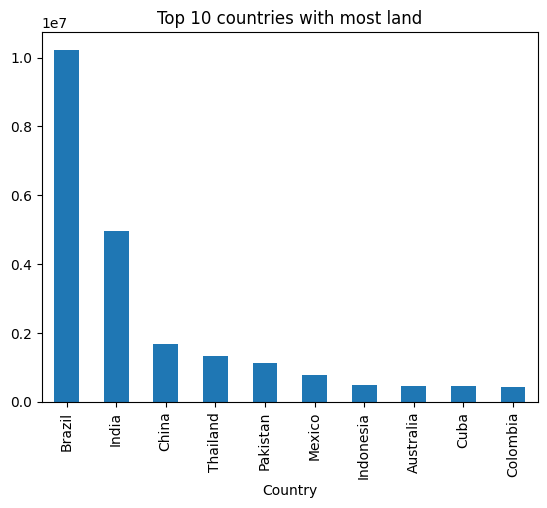

In [28]:
df_acr = df.sort_values(by='Acreage(Hectare)', ascending=False).set_index('Country')
df_acr.head(10)['Acreage(Hectare)'].plot(kind='bar', title='Top 10 countries with most land')

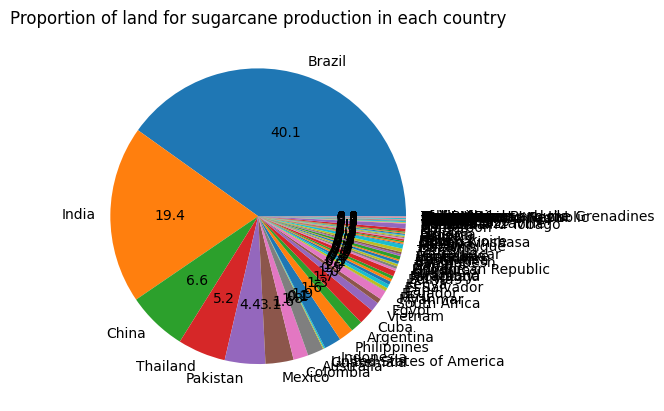

In [29]:
total_land = df['Acreage(Hectare)'].sum()
df_new = df[['Country', 'Acreage(Hectare)']].set_index('Country')
df_new['AcreagePercent'] = df_new['Acreage(Hectare)'] / (total_land / 100)

plt.pie(df_new['AcreagePercent'], labels=df_new.index, autopct='%.1f')
plt.title('Proportion of land for sugarcane production in each country')
plt.show()

### **Which country has highest yield per hectare?**

In [30]:
print('country with highest yield per hectare:')
df[df['Yield(Kg/Hectare)'] == df['Yield(Kg/Hectare)'].max()]

country with highest yield per hectare:


,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
8,Guatemala,North America,33533403.0,1938.114,25985.0,129049.3


<Axes: title={'center': 'Top 10 countries with highest yield per hectare'}, xlabel='Country'>

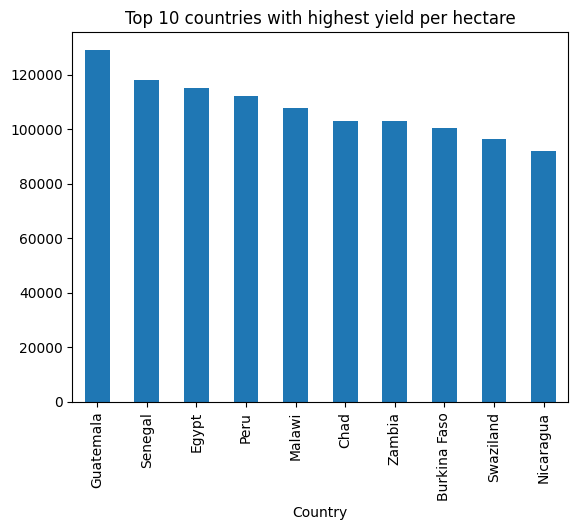

In [31]:
df_yld = df.sort_values(by='Yield(Kg/Hectare)', ascending=False).set_index('Country')
df_yld.head(10)['Yield(Kg/Hectare)'].plot(kind='bar', title='Top 10 countries with highest yield per hectare')

### **Which country has highest production per person?**

In [32]:
print('country with highest production per person:')
df[df['Production_per_person(Kg)'] == df['Production_per_person(Kg)'].max()]

country with highest production per person:


,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
25,Paraguay,South America,6708000.0,951087.0,120.0,559.0


<Axes: title={'center': 'Top 10 countries with highest production per person'}, xlabel='Country'>

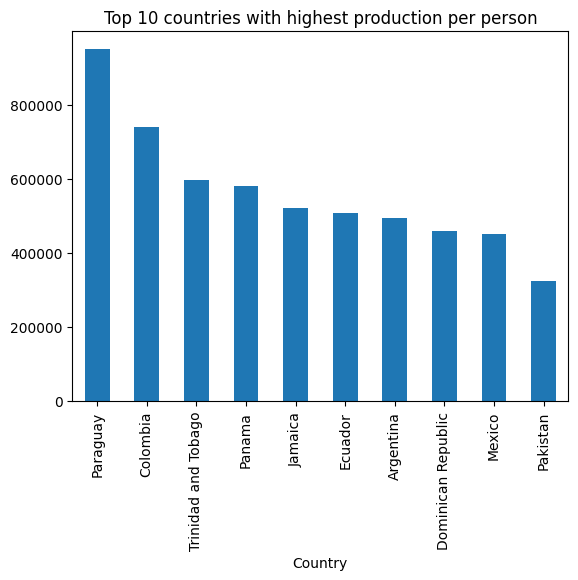

In [33]:
df_ppp = df.sort_values(by='Production_per_person(Kg)', ascending=False).set_index('Country')
df_ppp.head(10)['Production_per_person(Kg)'].plot(kind='bar', title='Top 10 countries with highest production per person')

### **Correlation**

In [34]:
df_corr = df[['Production(Tons)', 'Production_per_person(Kg)', 'Acreage(Hectare)', 'Yield(Kg/Hectare)']].corr()
df_corr

,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_person(Kg),0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

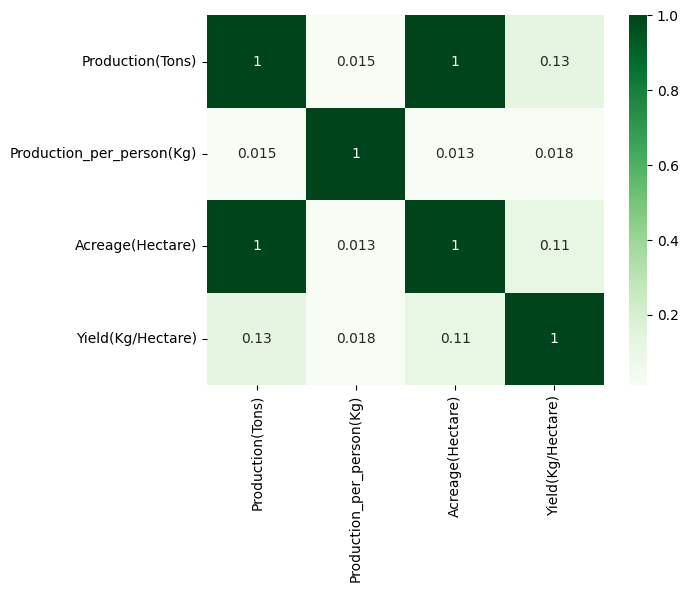

In [35]:
sns.heatmap(df_corr, annot=True, cmap='Greens')

### **Do countries with more land produce more sugarcane?**

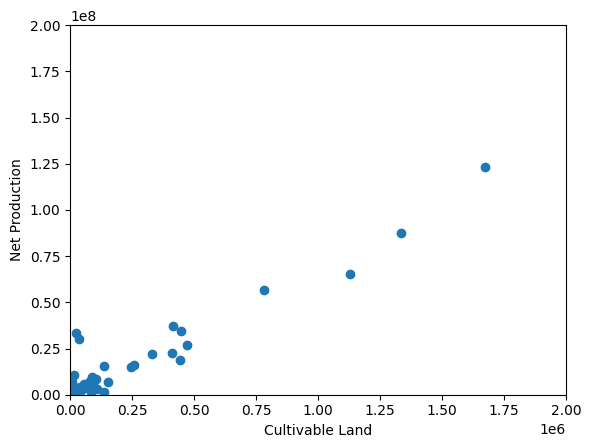

In [36]:
plt.scatter(x=df['Acreage(Hectare)'], y=df['Production(Tons)'])
plt.xlabel('Cultivable Land')
plt.ylabel('Net Production')

plt.xlim(0, (0.2 * 10 ** 7))
plt.ylim(0, (2 * 10 ** 8))
plt.show()

### **Do countries which yield more sugarcane per hectare produce more sugarcane in total?**

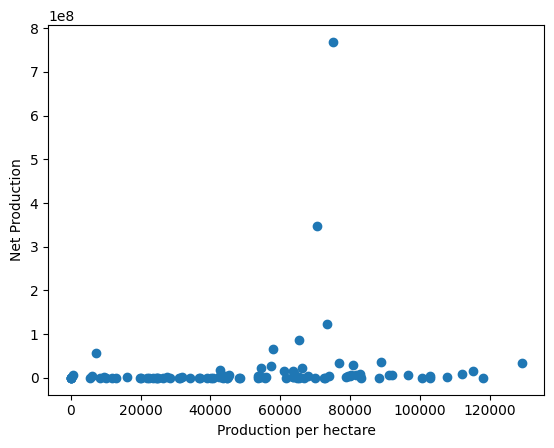

In [37]:
plt.scatter(x=df['Yield(Kg/Hectare)'], y=df['Production(Tons)'])
plt.xlabel('Production per hectare')
plt.ylabel('Net Production')
plt.show()

# **Analysis for Continent**

In [38]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


### **Which continent produces maximum sugarcane?**

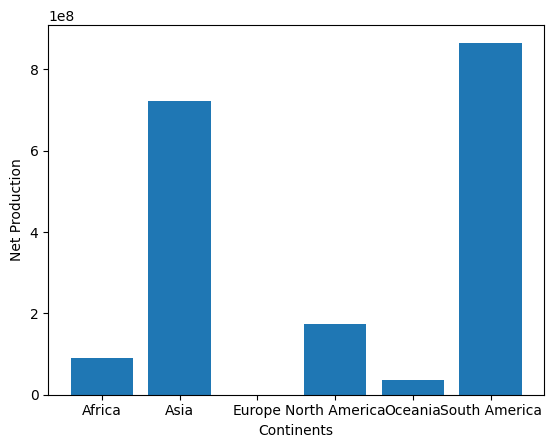

In [39]:
produce_per_continent = df.groupby(by='Continent').sum()['Production(Tons)']

plt.bar(x=produce_per_continent.index, height=produce_per_continent)
plt.xlabel('Continents')
plt.ylabel('Net Production')
plt.show()